In [1]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

import torch.nn as nn
import torch.nn.functional as F
from sbi import inference
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from  subhalo_impact import chi_eval
from rotation_matrix import obs_from_pos6d

In [4]:
from typing import Tuple, Optional
import torch
import torch.nn.functional as F
from torch import Tensor
import rnn

In [11]:
def replace_with_neighboring_value(values, values_stats, empty_bin_indices, phi1, phi1_edges):
    values_stats = np.copy(values_stats)
    for i in empty_bin_indices:
        neighboring_bin1 = i-1
        neighboring_bin2 = i+1
        
        while neighboring_bin1 in empty_bin_indices:
            neighboring_bin1 -= 1
        
        while neighboring_bin2 in empty_bin_indices:
                neighboring_bin2 += 1
        
        median, _, _ = scipy.stats.binned_statistic(phi1, values, statistic='median', bins = 1, range = (phi1_edges[neighboring_bin1], phi1_edges[neighboring_bin2+1]))
        values_stats[i] = median[0]
    return values_stats

In [12]:
def replace_with_neighboring_value_std(std_stats, empty_bin_indices):
    std_stats = np.copy(std_stats)
    for i in empty_bin_indices:
        neighboring_bin1 = i-1
        neighboring_bin2 = i+1
        
        while neighboring_bin1 in empty_bin_indices:
            neighboring_bin1 -= 1
        
        while neighboring_bin2 in empty_bin_indices:
                neighboring_bin2 += 1
        
        std_stats[i] = np.median([std_stats[neighboring_bin1], std_stats[neighboring_bin2]])
    return std_stats

In [14]:
def simulator (params, scatter = 0.1, bins = 100):
    params = np.array(params, dtype=float) # convert tensor to np ndarray
    log_Msat = params[0]
    M_sat = 10**log_Msat
    # vz = params[1]
    # r = params[2]

    vz = -20
    r = 0.2
    phi = 250 # angle around stream in dec
    vphi = 35  # velocity around stream in km/s
    t_a = 0.2 # time since interaction in Gyr
    phi_a = -4 # interaction point along stream in deg, phi=0 is progenitor location (try -20 to 10)
    rs_sat = 1.05 * (M_sat*10*10)**0.5 # scale radius of subhalo in kpc, can be adjusted along with M_sat using equation 15 in erkal et al. 2015
    pid=36 # index included in saved filenames
    tmax=4 # how long stream disrupts in Gyr

    chi_eval(r,phi,vphi,vz,M_sat,tmax,t_a,phi_a,rs_sat,pid)
    data = np.genfromtxt(f'final_stream/final_stream_{pid}.txt')
    R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
    phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

    '''to include in the output:
        phi1 edges
        fraction = count / len(phi1)
        phi2 median
        vr median

        phi2 std
        vr std
    '''

    phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
    phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
    count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
    vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
    vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)

    '''fill in empty bins with neighboring values'''
    nan_indices = np.argwhere(np.isnan(phi2_median)).flatten()
    phi2_median_new = replace_with_neighboring_value(phi2, phi2_median, nan_indices, phi1, phi1_edges)
    vr_median_new = replace_with_neighboring_value(vr, vr_median, nan_indices, phi1, phi1_edges)

    phi2_std_new = replace_with_neighboring_value_std(phi2_std, nan_indices)
    vr_std_new = replace_with_neighboring_value_std(vr_std, nan_indices)


    output = np.concatenate((phi1_edges, phi2_median_new, count/len(phi1), vr_median_new, phi2_std_new, vr_std_new))
    output = torch.from_numpy(output)
    return output + torch.randn_like(output) * scatter

In [15]:
# # log M_sat, r, vz
# num_dim = 3

# # need to change to more accurate distributions (range, mean, etc.)
# prior_min = [0.00001, -50, 0]
# prior_max = [10, 0, 30]


num_dim = 1
prior_min = [-5]
prior_max = [1]

prior_uniform = utils.BoxUniform(low = torch.as_tensor(prior_min), high=torch.as_tensor(prior_max))

prior_normal = torch.distributions.MultivariateNormal(5 * torch.ones(num_dim), 1 * torch.eye(num_dim))

In [16]:
# test the embedding net, comment in to run
# define RNN parameters
n_in = 2  # number of input channels
n_out = 10  # number of output channels
num_layers = 2  # number of recurrent layers
hidden_features = 8  # number of hidden features

# other parameters
batch_size = 16  # number of samples in a batch
seq_len = 100  # length of the sequence

x = torch.randn(batch_size, seq_len, n_in)
embedding_net = rnn.EmbeddingNet(n_in, n_out, hidden_features, num_layers)

# instantiate the neural density estimator
neural_posterior = utils.posterior_nn(
    model="maf", embedding_net=embedding_net(x, return_h = True), hidden_features=8, num_transforms=2
)

# setup the inference procedure with the SNPE-C procedure
inference = SNPE(prior=prior_uniform, density_estimator=neural_posterior)

In [24]:
# run the inference procedure on one round and 10000 simulated data points
theta, x = simulate_for_sbi(simulator, prior_uniform, num_simulations=10)

Running 10 simulations.:   0%|          | 0/10 [00:00<?, ?it/s]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [0.64593151]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential


Running 10 simulations.:  10%|█         | 1/10 [00:41<06:17, 41.99s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [6.51762881]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential


Running 10 simulations.:  20%|██        | 2/10 [01:23<05:34, 41.84s/it]

...

Running 10 simulations.:  80%|████████  | 8/10 [05:35<01:24, 42.03s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [0.10529693]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential


Running 10 simulations.:  90%|█████████ | 9/10 [06:19<00:42, 42.61s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [0.07904301]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential


Running 10 simulations.: 100%|██████████| 10/10 [07:01<00:00, 42.12s/it]


In [26]:
print(x)

tensor([-3.0521e+01, -2.9302e+01, -2.8045e+01,  ..., -1.8066e-02,
         2.0936e-02, -5.8218e-02], dtype=torch.float64)


In [ ]:
density_estimator = inference.append_simulations(theta, x).train()
posterior = inference.build_posterior(density_estimator)

In [35]:
posterior = infer(simulator, prior_uniform, "SNPE", num_simulations=100)

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  [14.48179775]
Impact pid: 36 with M_sat=0.000000, rs_sat=0.000000,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  11.038381936924326
Impact pid: 36 with M_sat=1.105178, rs_sat=11.0383

Running 100 simulations.:   0%|          | 0/100 [00:00<?, ?it/s]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.32331510726181034
Impact pid: 36 with M_sat=0.000948, rs_sat=0.323315,  
Sanity check : Initializing potential


Running 100 simulations.:   1%|          | 1/100 [00:42<1:09:22, 42.04s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.040087531131896524
Impact pid: 36 with M_sat=0.000015, rs_sat=0.040088,  
Sanity check : Initializing potential


...

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.44837654446848657
Impact pid: 36 with M_sat=0.001824, rs_sat=0.448377,  
Sanity check : Initializing potential


Running 100 simulations.:  99%|█████████▉| 99/100 [1:07:37<00:40, 40.70s/it]

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.36088936727487836
Impact pid: 36 with M_sat=0.001181, rs_sat=0.360889,  
Sanity check : Initializing potential


Running 100 simulations.: 100%|██████████| 100/100 [1:08:19<00:00, 40.99s/it]
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/sbi/neural_nets/flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  warn("In one-dimensional output space, this flow is limited to Gaussians")


 Neural network successfully converged after 55 epochs.

In [37]:
observation1 = simulator(torch.as_tensor([-5]))
observation2 = simulator(torch.as_tensor([-4]))
observation3 = simulator(torch.as_tensor([-3]))
observation4 = simulator(torch.as_tensor([-2]))
observation5 = simulator(torch.as_tensor([-1]))
observation6 = simulator(torch.as_tensor([0]))
observation7 = simulator(torch.as_tensor([1]))

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.03320391543176798
Impact pid: 36 with M_sat=0.000010, rs_sat=0.033204,  
Sanity check : Initializing potential
Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.10500000000000001
Impact pid: 36 with M_sat=0.000100, rs_sat=

In [38]:
posterior_samples_1 = posterior.sample((100000,), x=observation1)
posterior_samples_2 = posterior.sample((100000,), x=observation2)
posterior_samples_3 = posterior.sample((100000,), x=observation3)
posterior_samples_4 = posterior.sample((100000,), x=observation4)
posterior_samples_5 = posterior.sample((100000,), x=observation5)
posterior_samples_6 = posterior.sample((100000,), x=observation6)
posterior_samples_7 = posterior.sample((100000,), x=observation7)

Drawing 100000 posterior samples: 100034it [00:01, 51353.37it/s]                           
Drawing 100000 posterior samples: 100%|██████████| 100000/100000 [00:01<00:00, 52154.31it/s]
Drawing 100000 posterior samples: 100126it [00:02, 37169.73it/s]                           


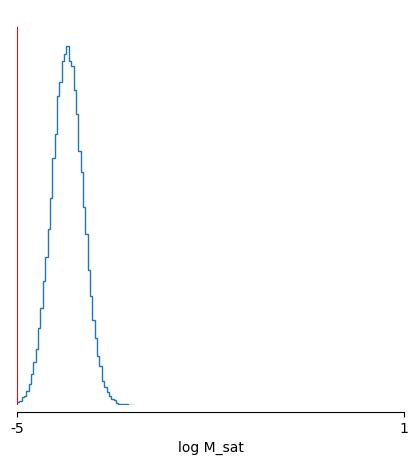

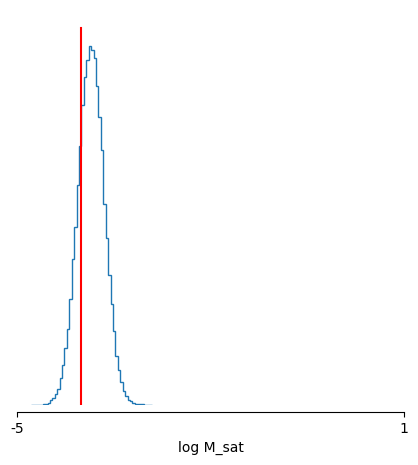

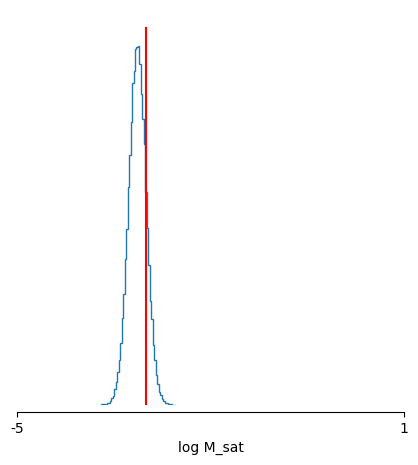

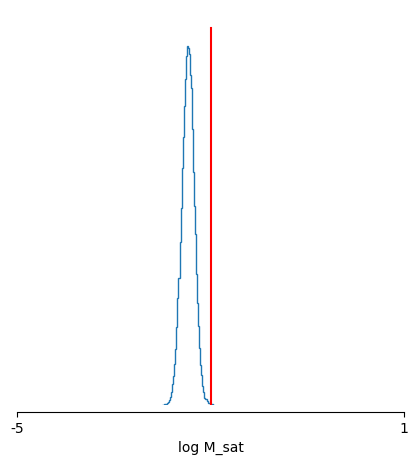

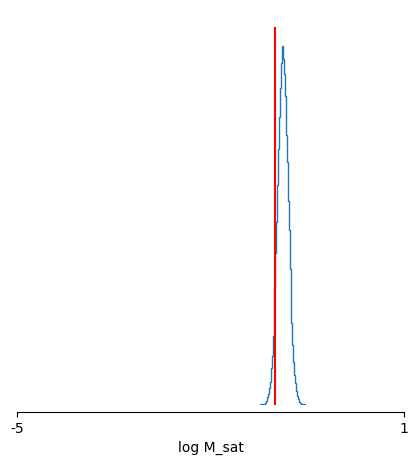

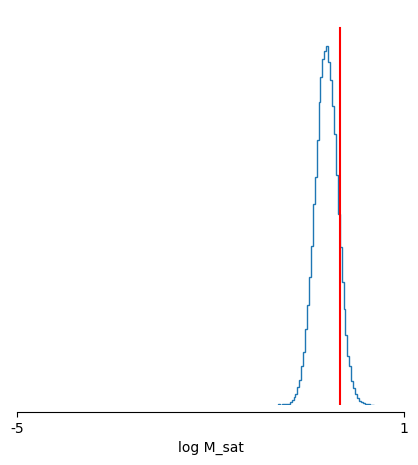

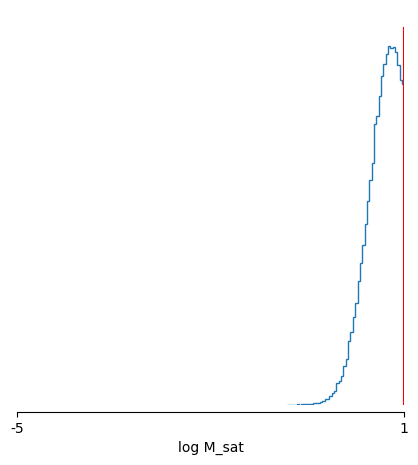

In [41]:
_ = analysis.pairplot(
    posterior_samples_1, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-5]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)

_ = analysis.pairplot(
    posterior_samples_2, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-4]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_3, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-3]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_4, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-2]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_5, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([-1]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_6, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([0]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)
_ = analysis.pairplot(
    posterior_samples_7, limits = [[-5,1]],
    ticks = [[-5,1]],
    figsize = (5, 5),
    points = np.array([1]),
    points_offdiag = {"markersize": 6},
    points_colors = "r",
    labels = ["log M_sat"]
)

In [120]:
def hpd(trace, mass_frac):
    ''' 
    Returns highest probability density region given by a set of samples.

    Parameters
    ----------
    trace: array
        1D array of MCMC samples for a single variable
    mass_frac: float with 0 < mass_frac <= 1
        The fraction of the probability to be included in the HPD. For example, 'massfrac'=0.95 gives a 95% HPD.

    Returns
    -------
    output: array, shape(2,)
        The bounds of the HPD
    '''

    # Get sorted list
    d = np.sort(np.copy(trace))

    # Number of total samples taken
    n = len(trace)

    # Get number of samples that should be included in HPD
    n_samples = np.floor(mass_frac * n).astype(int)

    # Get width (in units of data) of all intervals with n_samples samples
    int_width = d[n_samples:] - d[:n-n_samples]

    # Pick out minimal interval
    min_int = np.argmin(int_width)

    # Return interval
    return np.array([d[min_int], d[min_int+n_samples]])

In [121]:
# simple version

def draw_coverage_plot_1d(simulator, posterior, true_values):
    fractions = np.array([])
    x = np.arange(0, 1, 0.1)

    samples = [[0] for _ in range(len(true_values))]
    for i in range(len(true_values)):
        simulated_samples = posterior.sample((1000,), x = simulator(torch.as_tensor([true_values[i]])))[:,0]
        samples[i] = np.array(simulated_samples)
    
    for confidence in x:
        contain_true = 0
        for i in range(len(true_values)):
            lower, upper = hpd(samples[i],confidence)
            if lower <= true_values[i] <= upper:
                contain_true += 1
        fractions = np.append(fractions, [contain_true/len(true_values)])

    plt.plot(x, fractions, label = 'model coverage')
    plt.plot([0,1],[0,1],color='r', label = 'perfect coverage')
    plt.ylim(0,1)
    plt.title("coverage for M_sat")
    plt.xlabel("confidence interval")
    plt.ylabel("covereage percentage")
    plt.show()

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential
tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.03320391543176798
Impact pid: 36 with M_sat=0.000010, rs_sat=0.033204,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1104it [00:00, 31402.03it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  0.10500000000000001
Impact pid: 36 with M_sat=0.000100, rs_sat=0.105000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35315.46it/s]            

...

tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  3.3203915431767985
Impact pid: 36 with M_sat=0.100000, rs_sat=3.320392,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1134it [00:00, 35673.98it/s]            

Setup pid: 36 with tmax=4.000000, t_approach=0.200000 
Sanity check : Initializing potential


tmax: 3.886260
final_t: 3.886260
diff: 0.000000
Running orbit with r=0.2,phi=250,vphi=35,vz=-20,tapproach=0.2,phiapproach=-4,pid=36
Orbit pid: 36 with x=-13.052411, y=-33.619492, z=-23.715755, vx=-59.608256, vy=25.286811, vz=-54.697573, tmax=0.204642,  
Sanity check : Initializing potential
Impact with scale radius:  10.5
Impact pid: 36 with M_sat=1.000000, rs_sat=10.500000,  
Sanity check : Initializing potential
0


Drawing 1000 posterior samples: 1132it [00:00, 35942.38it/s]            


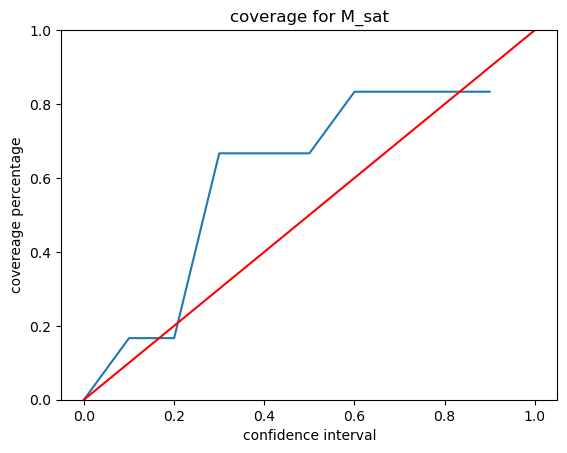

In [122]:
true_values = np.arange(-5, 1, 1)
draw_coverage_plot_1d(simulator, posterior, true_values)

In [78]:
bins = 100
pid = 36
data = np.genfromtxt(f'final_stream/final_stream_{pid}.txt')
R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])
phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

phi2_median, phi1_edges, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='median', bins = bins)
phi2_std, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='std', bins = bins)
count, _, _ = scipy.stats.binned_statistic(phi1, phi2, statistic='count', bins = bins)
vr_median, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='median', bins = bins)
vr_std, _, _ = scipy.stats.binned_statistic(phi1, vr, statistic='std', bins = bins)
# (phi1_edges, phi2_median, phi2_std, count/len(phi1), vr_median, vr_std)

# print(np.sum(np.isnan(phi1_edges)))
# print(np.sum(np.isnan(phi2_median)))
# print(np.sum(np.isnan(phi2_std)))
# print(phi1_edges)
# print(phi1_edges[:-1][count==0])
# print(min(phi1), max(phi1))
# print(np.sum(np.isnan(vr_median)))
# print(np.sum(np.isnan(vr_std)))

# print(np.sum(np.isnan(vr)))
# print(np.sum(np.isnan(phi2)))